In [31]:
# importing the required libraries
import scipy.io
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# data loading

In [32]:
# Load the data outputted from matlab (tracks_within_cells.mat)
file_path = '/Users/masoomeshafiee/Desktop/Bound2learn/Bound2Learn/Data/Rfa1_fast_549_60%_July28_batch/tracks_within_cells.mat'  # replace with your file path
ROG_path = '/Users/masoomeshafiee/Desktop/Bound2learn/Bound2Learn/Data/Rfa1_fast_549_60%_July28_batch/radius_of_gyration_final.mat'
ROG_dict = scipy.io.loadmat(ROG_path)
ROG = ROG_dict['radius_of_gyration_final']
mat = scipy.io.loadmat(file_path)
data_splitted = mat['tracks_within_cells']
data = np.concatenate(data_splitted)
data = np.vstack(data)
print((data.shape))
df = pd.DataFrame(data)
# Define the column names as in trackmate outputs
column_names = ["Track_IDs", "spt_tr", "spt_width", "mean_sp", "max_sp", "min_sp", "med_sp", "std_sp", "mean_q", "max_q_tr", "min_q_tr", "med_q_tr", "std_q_tr", "tr_dur", "tr_start", "tr_fin", "x_lc", "y_lc"]
df.columns = column_names
df['ROG'] = np.log(ROG)
print(df.head())


(4565, 18)
   Track_IDs  spt_tr  spt_width   mean_sp    max_sp    min_sp    med_sp  \
0       20.0     6.0   3.463235  1.676392  3.378392  0.528824  1.624043   
1       37.0     4.0   4.412565  1.569683  2.371238  0.846261  1.491550   
2       55.0     5.0   4.067581  0.336705  0.439391  0.202472  0.359445   
3       65.0    10.0   3.184305  2.086663  4.358771  0.284811  1.815298   
4       69.0     4.0   3.502557  2.012059  3.596240  0.658787  1.781149   

     std_sp      mean_q    max_q_tr    min_q_tr    med_q_tr    std_q_tr  \
0  1.134184  529.492686  721.808289  342.299591  555.227051  124.045815   
1  0.765485  394.993309  500.457581  347.109680  367.540222   61.394006   
2  0.098586  322.208667  449.600769  265.733368  286.339569   66.385008   
3  1.294779  524.837628  663.952148  360.238983  566.153564  117.516985   
4  1.482278  540.673431  592.437805  475.744080  579.793762   47.695523   

   tr_dur  tr_start  tr_fin        x_lc        y_lc       ROG  
0     5.0       0.0    

# data normalization

In [33]:
selected_features = ["mean_sp", "max_sp", "min_sp", "med_sp", "std_sp", "mean_q", "max_q_tr", "min_q_tr", "med_q_tr", "std_q_tr", "tr_dur", "ROG"]


In [37]:
X = df.loc[:, selected_features]

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the data and transform it ( the mean will be 0 and the standard deviation of 1)
X_normalized = pd.DataFrame(scaler.fit_transform(X),columns=selected_features)
X_normalized.head()

/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if no

,mean_sp,max_sp,min_sp,med_sp,std_sp,mean_q,max_q_tr,min_q_tr,med_q_tr,std_q_tr,tr_dur,ROG
0,0.654585,1.102429,-0.073438,0.548005,1.322641,0.391100,0.287665,0.327479,0.476678,0.243532,-0.292522,1.241666
1,0.469651,0.098046,0.634713,0.335315,0.291749,-0.582939,-0.700854,0.385578,-0.763384,-0.850153,-0.429510,0.419779
2,-1.667185,-1.828486,-0.801479,-1.482046,-1.572915,-1.110042,-0.927973,-0.597338,-1.299883,-0.763027,-0.361016,-1.923303
3,1.365612,2.080111,-0.617792,0.855025,1.771668,0.357388,0.029288,0.544163,0.548870,0.129561,-0.018545,1.370020
4,1.236317,1.319677,0.216487,0.800206,2.295918,0.472070,-0.290084,1.939309,0.638992,-1.089281,-0.429510,0.385170


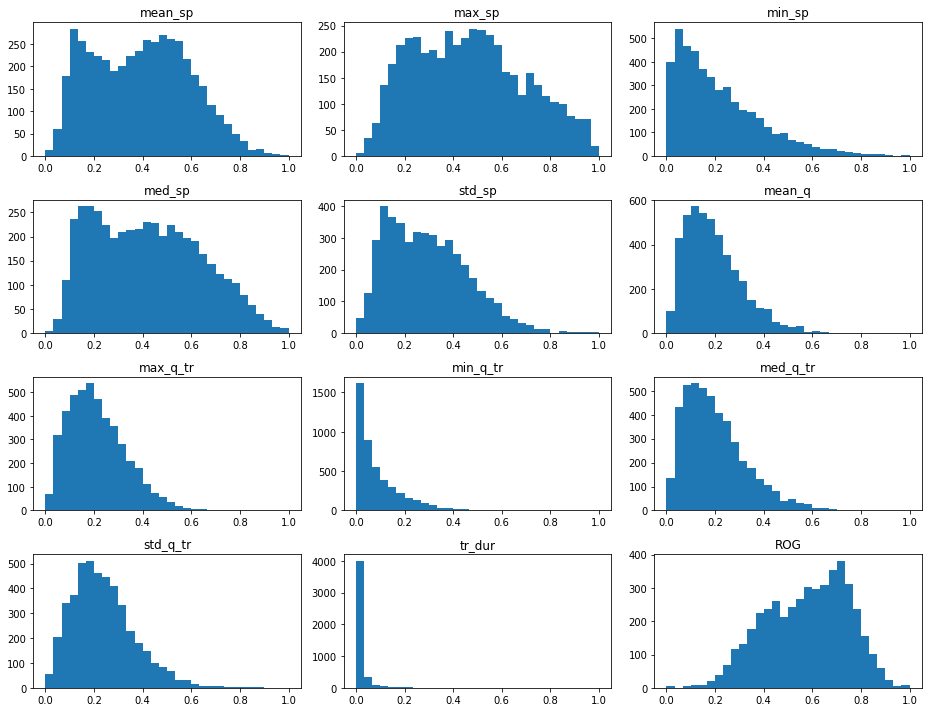

In [35]:
# Display histograms for all features (Each histogram provides a visual representation of the distribution of the data for each feature.)
#df.hist(figsize=(18, 10), bins=30, grid=False)
X_normalized.hist(figsize=(13, 10), bins=30, grid=False)
plt.tight_layout()  # tight_layout automatically adjusts the size and positions of the plots to fit them more cleanly within the figure.
plt.show()

# data visualization

In [104]:
# feature selection:
features = df.loc[:,["spt_width", "mean_sp", "max_sp", "min_sp", "med_sp", "std_sp", "mean_q", "max_q_tr", "min_q_tr", "med_q_tr", "std_q_tr", "tr_dur", "ROG"]]

## histogram

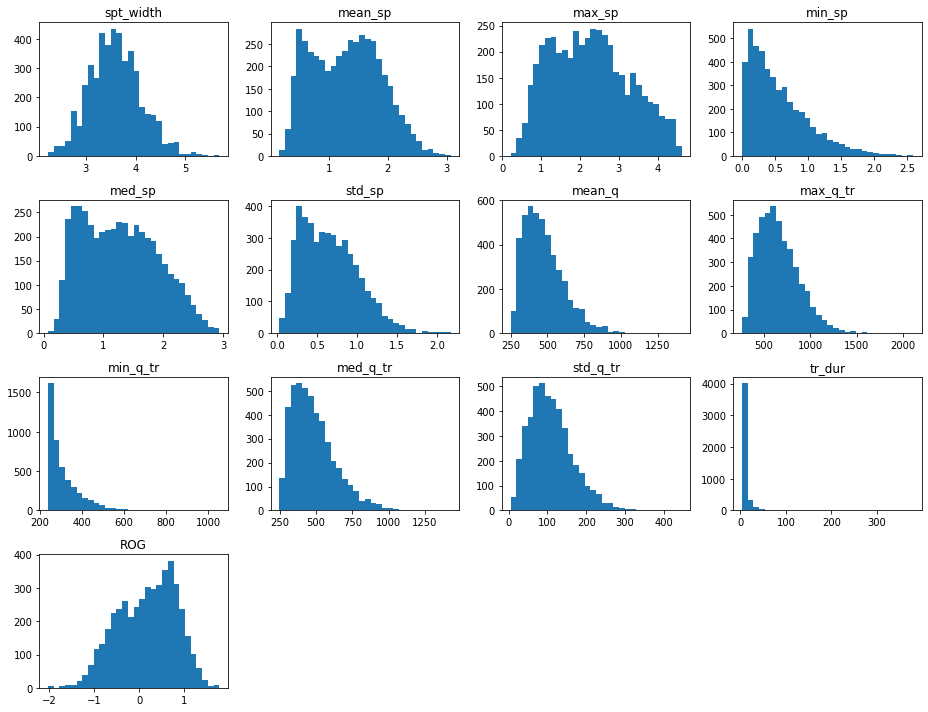

In [105]:
# Display histograms for all features (Each histogram provides a visual representation of the distribution of the data for each feature.)
#df.hist(figsize=(18, 10), bins=30, grid=False)
features.hist(figsize=(13, 10), bins=30, grid=False)
plt.tight_layout()  # tight_layout automatically adjusts the size and positions of the plots to fit them more cleanly within the figure.
plt.show()

## Density plot

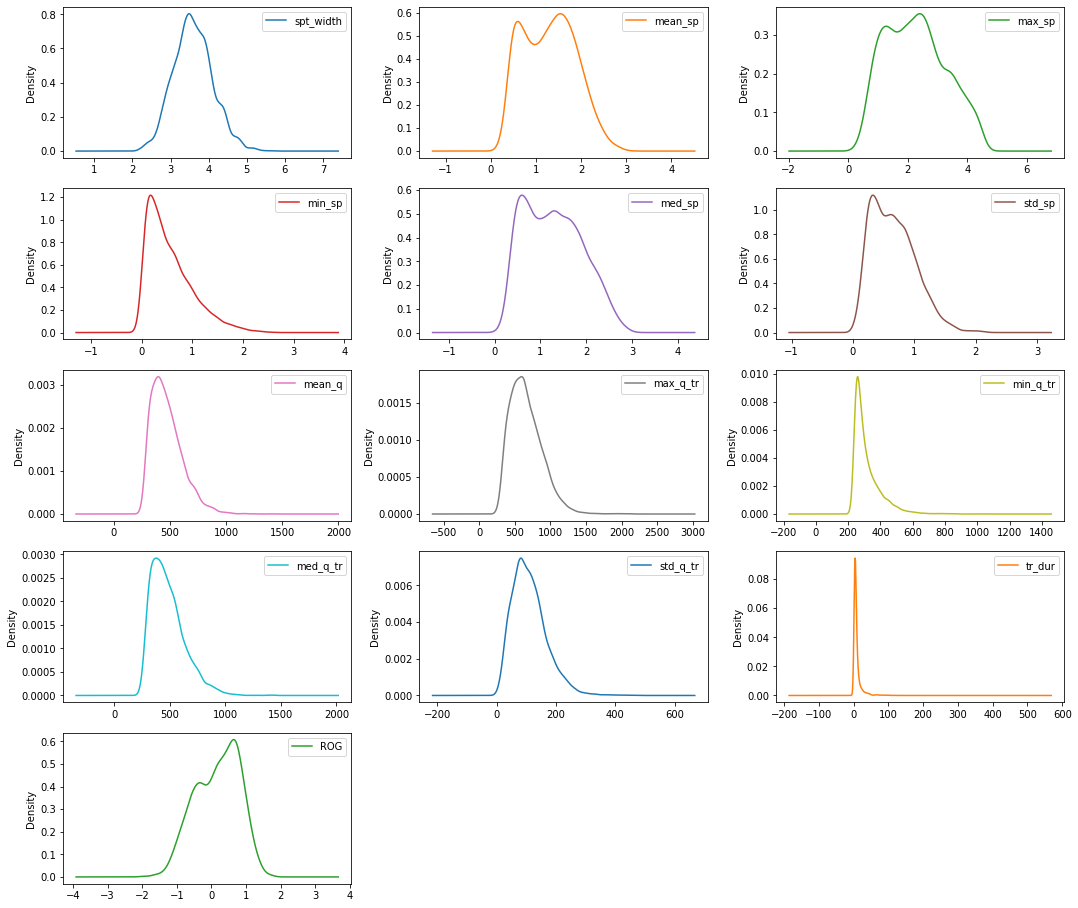

In [106]:
features.plot(kind='density', subplots=True, layout=(6,3), sharex=False, figsize=(15,15))
# The layout (6,3) is just an example, adjust based on the number of features in your dataset
plt.tight_layout()
plt.show()

## box plot

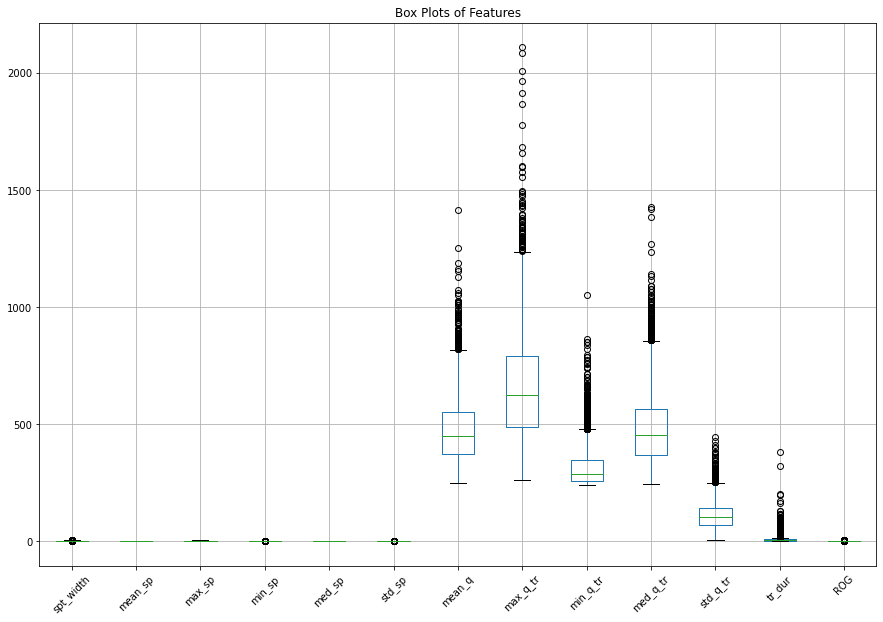

In [14]:
# For each feature, plot a box plot
plt.figure(figsize=(15, 10))
features.boxplot()
plt.xticks(rotation=45)  # Rotate x labels for better visibility
plt.title('Box Plots of Features')
plt.show()

## pair plot

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/homebrew/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

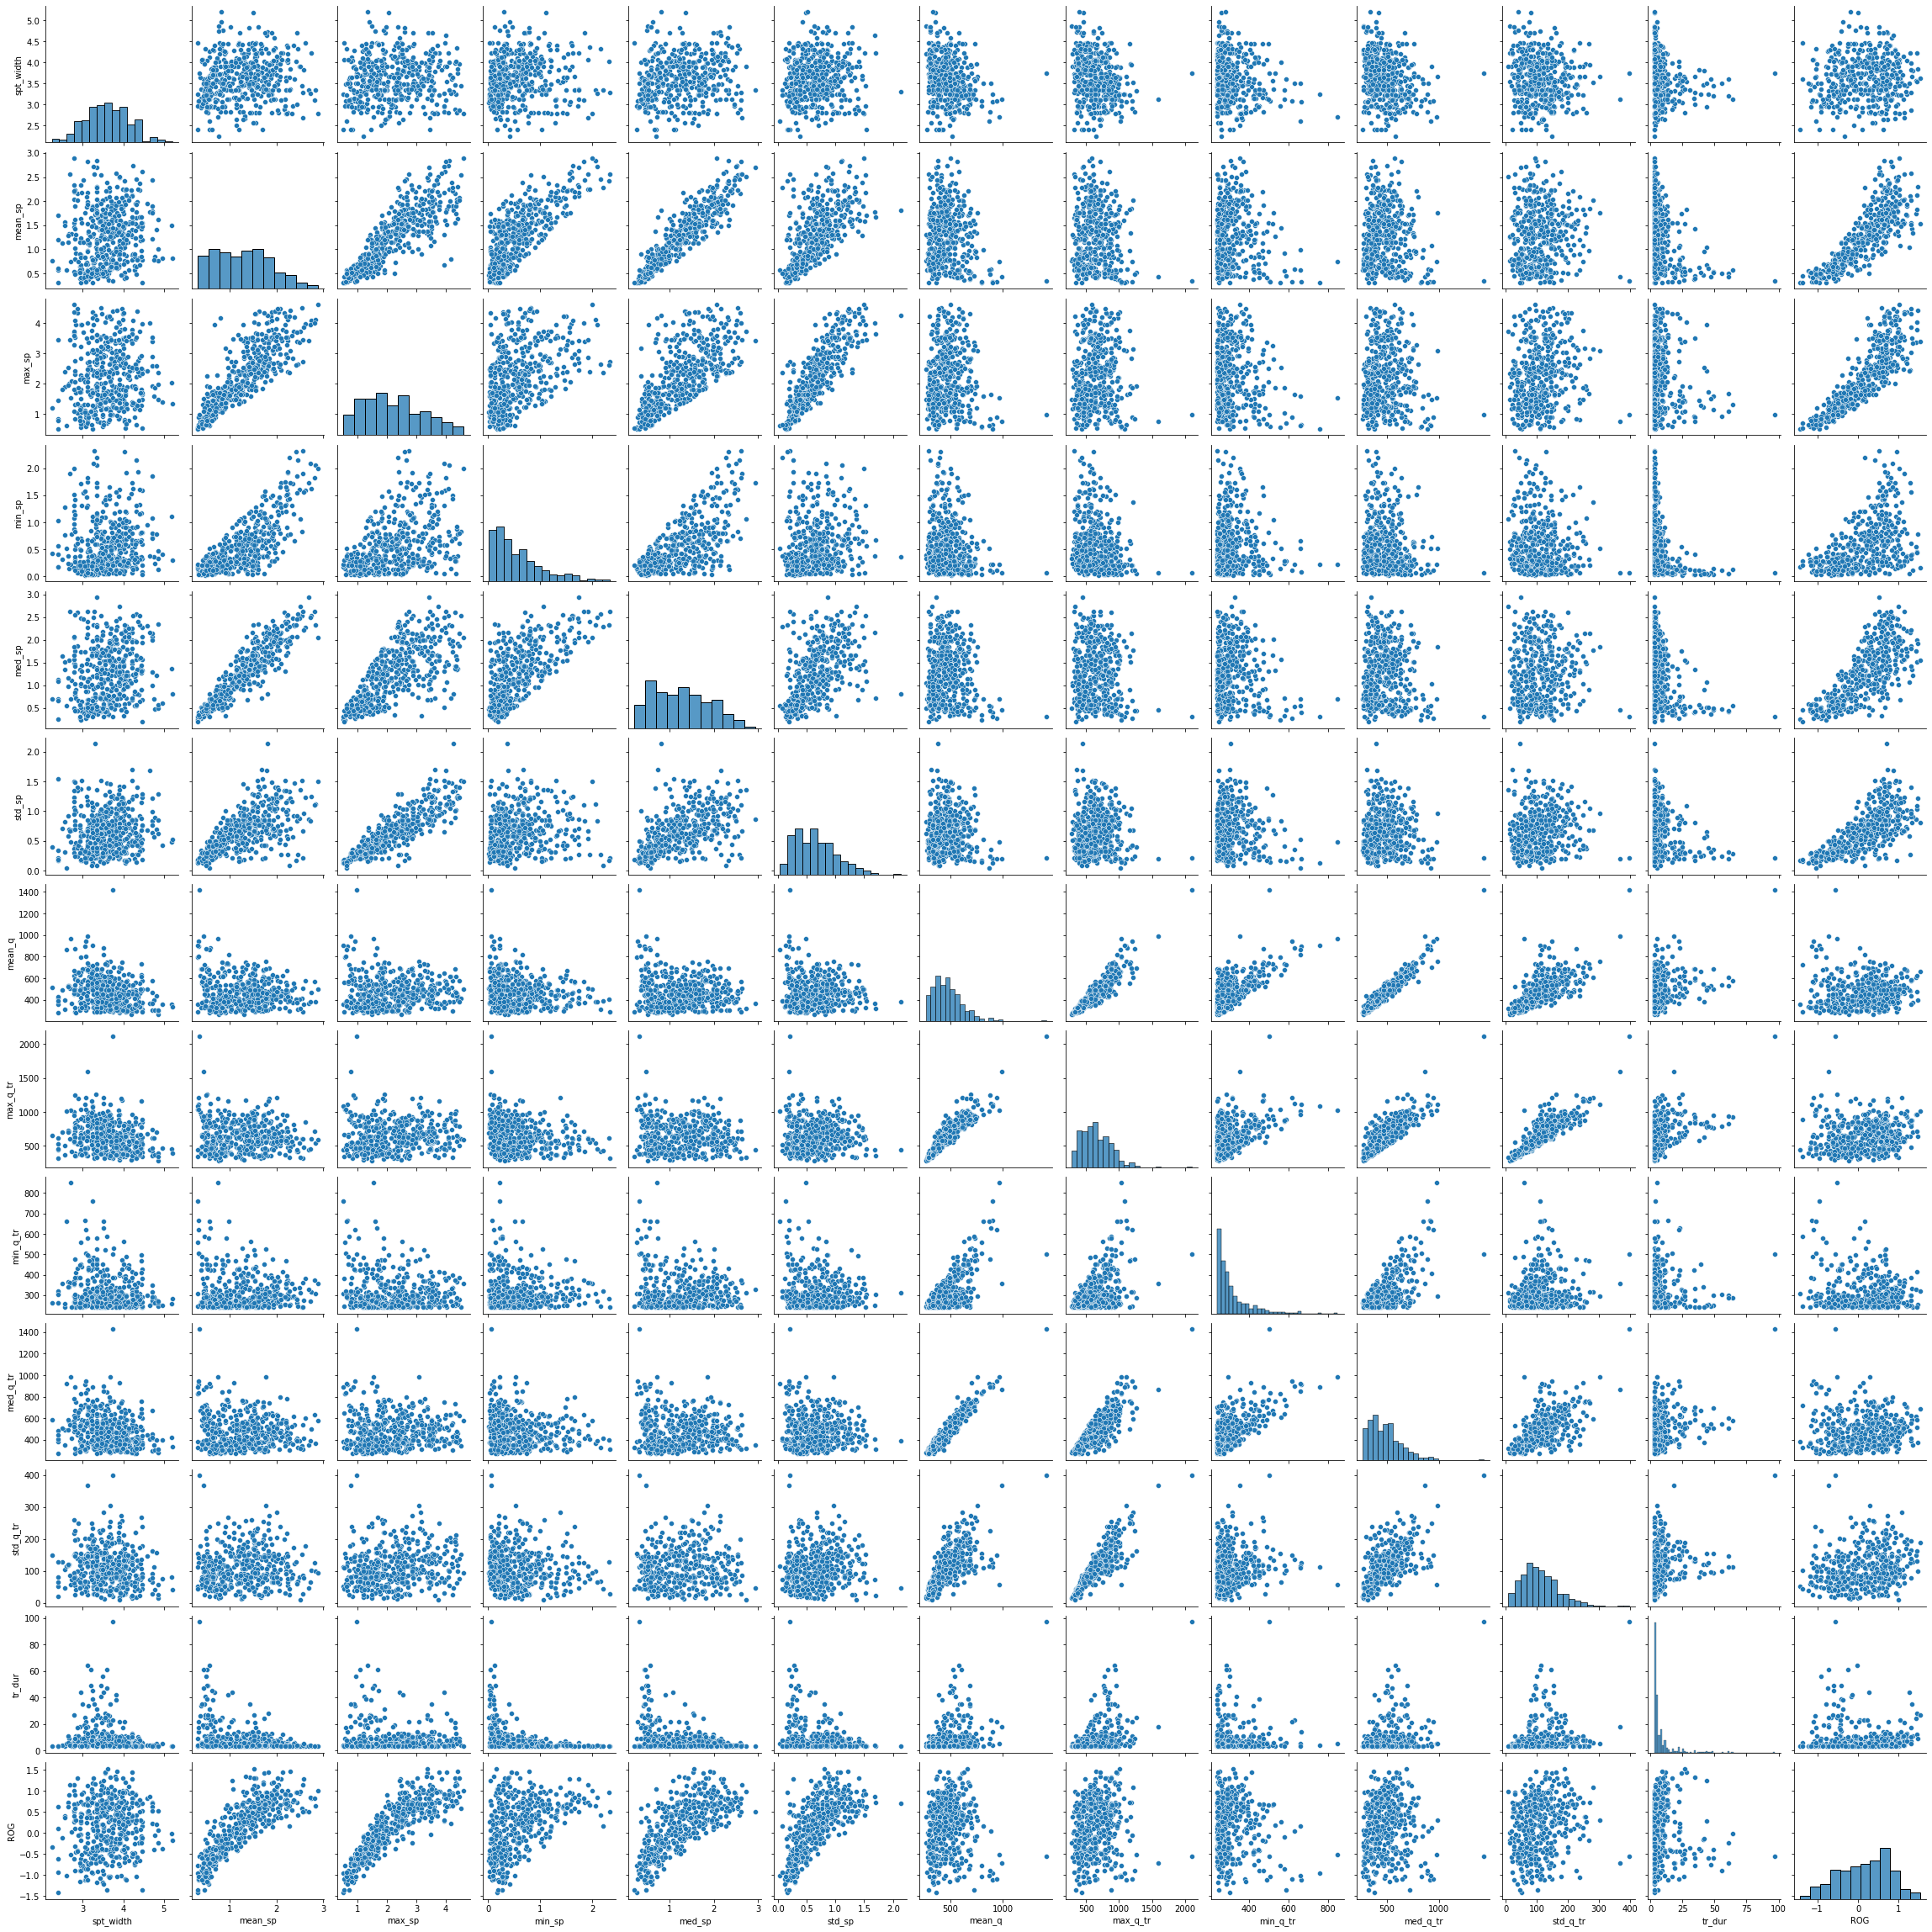

In [107]:
# Display pair plots (scatter plots of pairs of features)
# NOTE: This can be computationally intensive if you have many features or many rows. 
# You might want to select a subset of features or use a sample of your data.
sns.pairplot(features.sample(frac = 0.1))  # Here, using a 10% sample for demonstration
plt.show()

## corelation matrix and heatmap

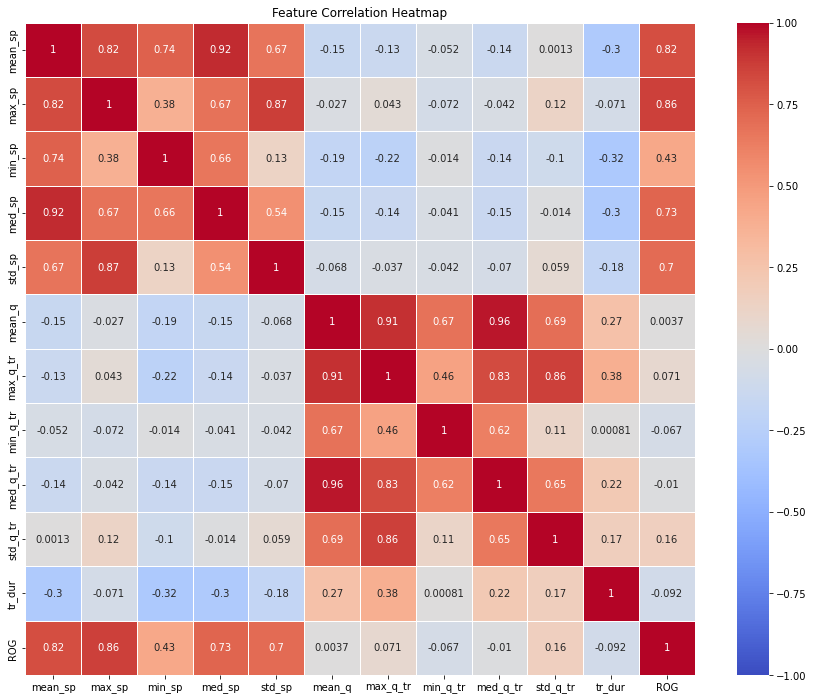

In [45]:
correlation_matrix = X_normalized.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()


 # k means clustering

In [41]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_normalized)
df['cluster'] = clusters

/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the war

# evaluation

In [42]:
silhouette_avg = silhouette_score(X_normalized, clusters)
print("Silhouette Score:", silhouette_avg)

/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


Silhouette Score: 0.2692596699012666


# PCA on speed and then quality

/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


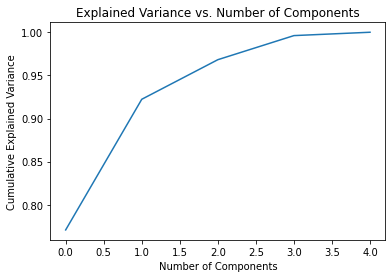

/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [72]:

scaled_data = X_normalized.loc[:,["mean_sp", "max_sp", "min_sp", "med_sp", "ROG"]]

# 2. Decide How Many Components to Keep
# Initialize PCA and fit to the scaled data
pca = PCA()
pca.fit(scaled_data)

# Plotting the explained variance for each component
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()

# Based on the plot, decide the number of components you want (e.g., where explained variance is >95%)

# 3. Apply PCA and Transform Data
n_components = 1  # replace this based on your decision from the plot
pca = PCA(n_components=n_components)
principal_components_speed = pca.fit_transform(scaled_data)

# 4. Use Transformed Data for Clustering
# Now you can use `principal_components` as your dataset for K-means clustering


/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


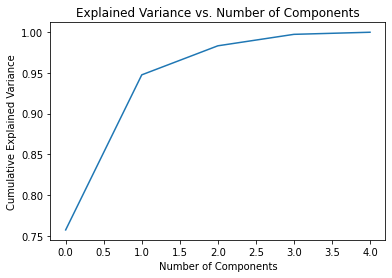

<class 'numpy.ndarray'>


/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


In [75]:

scaled_data_quality = X_normalized.loc[:,["mean_q", "max_q_tr", "min_q_tr", "med_q_tr", "std_q_tr" ]]

# 2. Decide How Many Components to Keep
# Initialize PCA and fit to the scaled data
pca = PCA()
pca.fit(scaled_data_quality)

# Plotting the explained variance for each component
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()

# Based on the plot, decide the number of components you want (e.g., where explained variance is >95%)

# 3. Apply PCA and Transform Data
n_components = 1  # replace this based on your decision from the plot
pca = PCA(n_components=n_components)
principal_components_quality = pca.fit_transform(scaled_data_quality)
print(type(principal_components_quality))
# 4. Use Transformed Data for Clustering
# Now you can use `principal_components` as your dataset for K-means clustering


In [78]:
# Concatenate the principal components and selected columns
X_new = np.concatenate(
    (principal_components_speed, principal_components_quality),
    axis=1
)

# Convert to DataFrame
X_new_df = pd.DataFrame(X_new)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_new_df)

# Assign cluster labels to the original dataframe
X_new_df['cluster'] = clusters

# Calculate silhouette score
silhouette_avg = silhouette_score(X_new_df, clusters)
print("Silhouette Score:", silhouette_avg)


/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the war

Silhouette Score: 0.38753665010000404


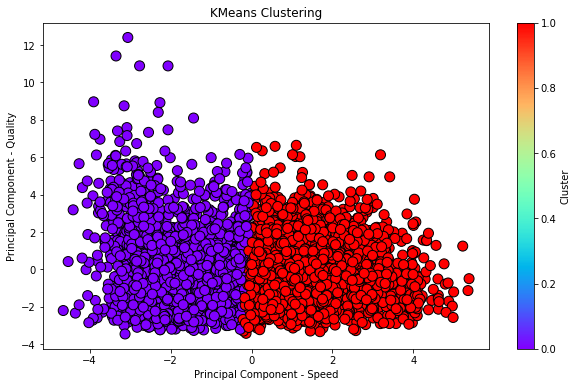

In [79]:

# Get the cluster assignments from your previous KMeans run
clusters = X_new_df['cluster']

# Create a scatter plot of the two principal components
plt.figure(figsize=(10, 6))
plt.scatter(principal_components_speed, principal_components_quality, c=clusters, cmap='rainbow', edgecolor='k', s=100)

# Label axes (assuming they represent the first principal component of speed and quality respectively)
plt.xlabel('Principal Component - Speed')
plt.ylabel('Principal Component - Quality')

# Add a title and display the plot
plt.title('KMeans Clustering')
plt.colorbar().set_label('Cluster')
plt.show()


## PCA
### features standardization

In [108]:

X = features.values  # Convert dataframe to numpy array

# Standardize the data
X_standardized = StandardScaler().fit_transform(X)
print(X_standardized.shape)
print(X_standardized)


(4565, 13)
[[-0.25428408  0.65458458  1.10242915 ...  0.24353191 -0.29252173
   1.24166637]
 [ 1.60078621  0.46965056  0.09804589 ... -0.85015307 -0.42951001
   0.41977878]
 [ 0.92665773 -1.66718479 -1.82848592 ... -0.76302736 -0.36101587
  -1.92330268]
 ...
 [-1.54080997 -1.51389066 -1.6396563  ... -0.70055637 -0.36101587
  -2.11504489]
 [-0.06245081 -1.47173321 -1.64928465 ... -1.03647804 -0.36101587
  -1.81990469]
 [ 1.3750718  -0.21569013 -0.56501229 ... -0.12373363 -0.42951001
  -0.71877631]]


### apply PCA

In [109]:
pca = PCA(n_components= features.shape[1])
principalComponents = pca.fit_transform(X_standardized)

#### Explained Variance Ratio:
This tells us the amount of information (variance) captured by each principal component.

In [110]:
explained_variance_ratio = pca.explained_variance_ratio_
#Print the explained variance for each component
for i, exp_var in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {exp_var*100:.2f}%")


Principal Component 1: 36.45%
Principal Component 2: 28.94%
Principal Component 3: 9.88%
Principal Component 4: 7.04%
Principal Component 5: 6.46%
Principal Component 6: 5.75%
Principal Component 7: 1.79%
Principal Component 8: 1.49%
Principal Component 9: 1.30%
Principal Component 10: 0.46%
Principal Component 11: 0.23%
Principal Component 12: 0.12%
Principal Component 13: 0.09%


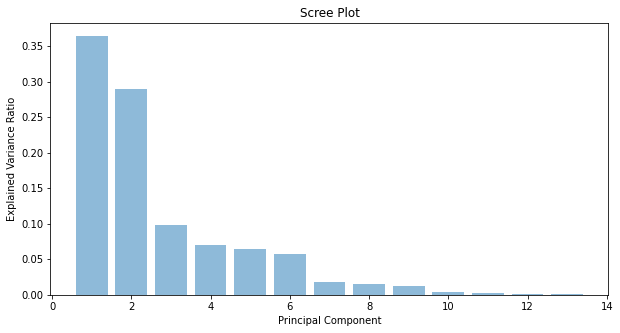

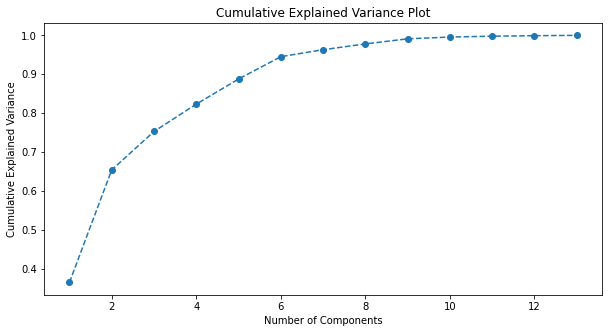

In [115]:
# Scree Plot
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center', label='Individual explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

# Cumulative Explained Variance Plot
cumulative_variances = np.cumsum(explained_variance_ratio)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variances) + 1), cumulative_variances, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance Plot')
plt.show()


### loading analysis to know how each feature contribute to each components:

In [117]:
loadings = pca.components_
# For example, to view loadings for the 1st principal component
first_component_loadings = loadings[0]
print("Loadings for the 1st Principal Component:")
for feature, loading in zip(features.columns, first_component_loadings):
    print(f"{feature}: {loading:.4f}")


Loadings for the 1st Principal Component:
spt_width: -0.1547
mean_sp: -0.4097
max_sp: -0.3471
min_sp: -0.2943
med_sp: -0.3799
std_sp: -0.3076
mean_q: 0.2485
max_q_tr: 0.2309
min_q_tr: 0.1517
med_q_tr: 0.2378
std_q_tr: 0.1377
tr_dur: 0.1847
ROG: -0.3384


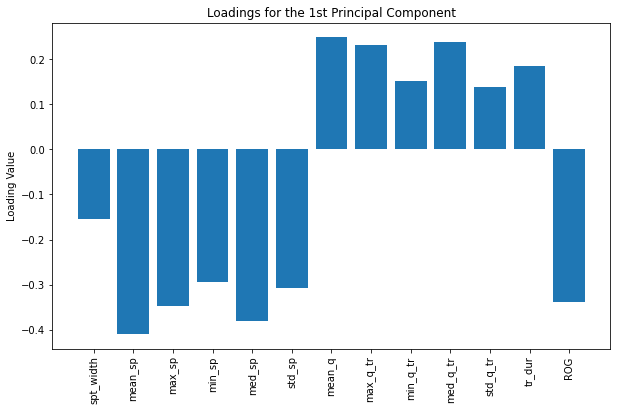

In [120]:
# Bar plot
# chose any component
plt.figure(figsize=(10, 6))
plt.bar(features.columns, loadings[0])
plt.title('Loadings for the 1st Principal Component')
plt.xticks(rotation=90)
plt.ylabel('Loading Value')
plt.show()


In [121]:
loadings_df = pd.DataFrame(loadings.T, columns=[f'PC{i+1}' for i in range(loadings.shape[0])], index=features.columns)
print(loadings_df)


                PC1       PC2       PC3       PC4       PC5       PC6  \
spt_width -0.154708 -0.089049  0.087764 -0.789903 -0.528239  0.235807   
mean_sp   -0.409689  0.203419 -0.113817 -0.018296  0.121966  0.062339   
max_sp    -0.347102  0.262167  0.248245  0.162304 -0.094770  0.051247   
min_sp    -0.294284  0.071801 -0.451825 -0.235877  0.447813  0.154990   
med_sp    -0.379861  0.174347 -0.164720 -0.070051  0.144126  0.066839   
std_sp    -0.307616  0.206540  0.286288  0.300958 -0.400705 -0.124611   
mean_q     0.248466  0.419325 -0.116814 -0.032173 -0.081239  0.044247   
max_q_tr   0.230905  0.420746  0.112238 -0.155164  0.073796 -0.053292   
min_q_tr   0.151671  0.260089 -0.492341  0.239412 -0.390172  0.371233   
med_q_tr   0.237775  0.401040 -0.153055 -0.033752 -0.069368  0.009983   
std_q_tr   0.137735  0.378423  0.194029 -0.334679  0.204208 -0.453814   
tr_dur     0.184742  0.079005  0.495005  0.010600  0.321781  0.736371   
ROG       -0.338410  0.270116  0.172432  0.050633  

### select the number of principle component

In [125]:

selected_components = principalComponents[:, :3]


### visualizing the principle components

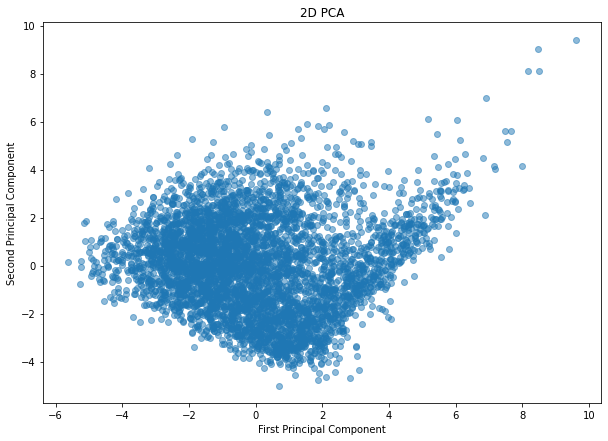

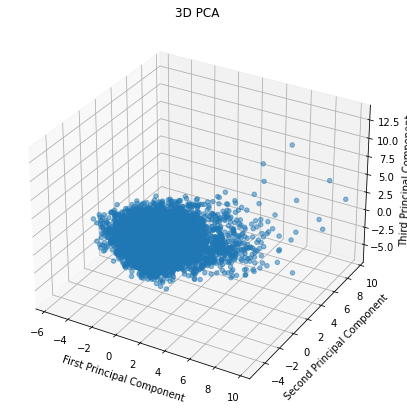

In [127]:
# 2D Visualization using the first two components
plt.figure(figsize=(10, 7))
plt.scatter(selected_components[:, 0], selected_components[:, 1], alpha=0.5)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D PCA')
plt.show()

# 3D Visualization (if you retained at least 3 components)
if k >= 3:
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(selected_components[:, 0], selected_components[:, 1], selected_components[:, 2], alpha=0.5)
    ax.set_xlabel('First Principal Component')
    ax.set_ylabel('Second Principal Component')
    ax.set_zlabel('Third Principal Component')
    plt.title('3D PCA')
    plt.show()


## K means clustering

### using PCs

In [128]:
# assuming we have two clusters (diffusing and bound)
kmeans = KMeans(n_clusters=2)
clusters = kmeans.fit_predict(selected_components)

/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


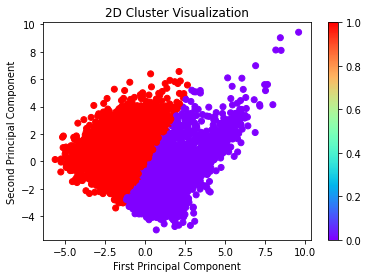

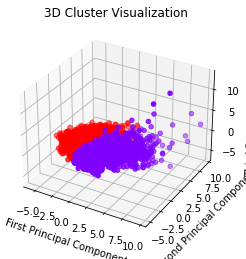

In [130]:

# For 2D visualization
if selected_components.shape[1] >= 2:
    plt.scatter(selected_components[:, 0], selected_components[:, 1], c=clusters, cmap='rainbow')
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.title('2D Cluster Visualization')
    plt.colorbar()
    plt.show()

# For 3D visualization
if selected_components.shape[1] >= 3:
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(selected_components[:, 0], selected_components[:, 1], selected_components[:, 2], c=clusters, cmap='rainbow')
    ax.set_xlabel('First Principal Component')
    ax.set_ylabel('Second Principal Component')
    ax.set_zlabel('Third Principal Component')
    ax.set_title('3D Cluster Visualization')
    plt.show()


In [131]:
centroids = kmeans.cluster_centers_
print(centroids)


[[ 1.79859231 -0.91656556 -0.00718286]
 [-1.45312013  0.74051237  0.00580319]]


In [135]:
features['Cluster'] = clusters
for cluster_num in set(clusters):
    print(f"Cluster {cluster_num}:")
    print(features[features['Cluster'] == cluster_num].describe())


Cluster 0:
         spt_width      mean_sp       max_sp       min_sp       med_sp  \
count  2040.000000  2040.000000  2040.000000  2040.000000  2040.000000   
mean      3.494251     0.765204     1.419341     0.302142     0.749461   
std       0.503571     0.267666     0.563209     0.242528     0.304425   
min       2.240000     0.162631     0.219235     0.000000     0.075244   
25%       3.128771     0.541401     1.010018     0.114350     0.508020   
50%       3.466243     0.740190     1.354838     0.229774     0.701455   
75%       3.814146     0.982072     1.743879     0.429298     0.964031   
max       5.438330     1.437623     4.292870     1.291067     1.694258   

            std_sp       mean_q     max_q_tr     min_q_tr     med_q_tr  \
count  2040.000000  2040.000000  2040.000000  2040.000000  2040.000000   
mean      0.397850   483.610780   664.074605   318.546248   491.527254   
std       0.185233   163.304341   256.077383    94.018098   176.572514   
min       0.028425   249.1

In [136]:
silhouette_avg = silhouette_score(selected_components, clusters)
print(f"Silhouette Score: {silhouette_avg}")


Silhouette Score: 0.3291172156493988


In [96]:
kmeans = KMeans(n_clusters=2)
ROG_DF = pd.DataFrame(np.log(ROG))
ROG_DF.columns = ['ROG']
clusters = kmeans.fit_predict(ROG_DF)
silhouette_avg = silhouette_score(selected_components, clusters)
ROG_DF['cluster'] = clusters
print(f"Silhouette Score: {silhouette_avg}")
for cluster_num in set(clusters):
    print(f"Cluster {cluster_num}:")
    print(ROG_DF[ROG_DF['cluster'] == cluster_num].describe())


/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/homebrew/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the war

Silhouette Score: 0.2895594394794634
Cluster 0:
               ROG  cluster
count  1923.000000   1923.0
mean     -0.459622      0.0
std       0.364407      0.0
min      -2.018028      0.0
25%      -0.699356      0.0
50%      -0.416709      0.0
75%      -0.165105      0.0
max       0.087509      0.0
Cluster 1:
               ROG  cluster
count  2642.000000   2642.0
mean      0.633812      1.0
std       0.327861      0.0
min       0.087880      1.0
25%       0.368739      1.0
50%       0.622211      1.0
75%       0.857247      1.0
max       1.774391      1.0


AttributeError: Rectangle.set() got an unexpected keyword argument 'c'

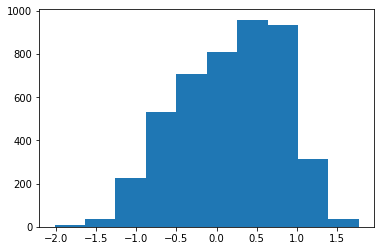

In [101]:

plt.hist(ROG_DF['ROG'], c=clusters)

plt.title('Clusters Visualization')
plt.colorbar()
plt.show()